# Simplified Research Agent - Using LangGraph Built-ins

## 🎯 Goal: Show that `create_react_agent` is MUCH simpler

### Why use `create_react_agent`?

Instead of manually building:
- State classes
- Agent nodes
- Tool nodes
- Routing functions
- Graph edges

**LangGraph does it all for you!**

### What it handles:
- ✅ Agent loop (think → act → observe → repeat)
- ✅ Tool execution
- ✅ State management
- ✅ Routing logic
- ✅ Message tracking

In [1]:
# Setup
import dotenv
import os

dotenv.load_dotenv("../env_workshop")

%load_ext autoreload
%autoreload 2

import requests
from datetime import datetime

OPENAI_BASE_URL = os.environ.get("OPENAI_BASE_URL")
TAVILY_BASE_URL = os.environ.get("TAVILY_BASE_URL")

print("✅ Environment loaded")

✅ Environment loaded


In [2]:
from phoenix.otel import register
from openinference.instrumentation.langchain import LangChainInstrumentor
from opentelemetry import trace

PHOENIX_PROJECT_NAME=os.environ.get("PHOENIX_PROJECT_NAME")

if os.environ.get("PHOENIX_COLLECTOR_ENDPOINT"):
    # configure the Phoenix tracer
    tracer_provider = register(
    project_name=PHOENIX_PROJECT_NAME, 
    auto_instrument=False 
    )
    LangChainInstrumentor().instrument(tracer_provider=tracer_provider)
else:
    dummy_tracer_provider = NoOpTracerProvider()

tracer = trace.get_tracer(__name__)

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: npatta01
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: llm-tracing.np-training.dev:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



## Step 1: Define Tools (Same as Before)

Tools don't change - we still need `web_search`, `think`, and `summarize_findings`

In [3]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.messages import AIMessage

from pydantic import BaseModel, Field

# Helper classes and functions
class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts")


def tavily_search_helper(query: str, max_results: int = 3, **kw):
    """Call Tavily API."""
    r = requests.post(
        TAVILY_BASE_URL,
        json={"query": query, "max_results": max_results, **kw},
        timeout=180
    )
    r.raise_for_status()
    return r.json()


def summarize_webpage_content(webpage_content) -> str:
    """Summarize webpage content."""
    if not webpage_content:
        return "No content available from this source."

    if not isinstance(webpage_content, str):
        webpage_content = str(webpage_content)


    try:
        summarization_model = ChatOpenAI(
            model="gpt-4o-mini",
            base_url=OPENAI_BASE_URL,
        ).with_structured_output(Summary)

        summary = summarization_model.invoke([
            HumanMessage(content=f"""Summarize this webpage content:

{webpage_content}

Extract the key information and important excerpts.""")
        ])

        return (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )
    except Exception as e:
        print(f"Summarization failed: {e}")
        trimmed = webpage_content if len(webpage_content) <= 1000 else webpage_content[:1000] + "..."
        return trimmed


print("✅ Helper functions defined")

✅ Helper functions defined


In [4]:
@tool
def web_search(query: str, max_results: int = 3) -> str:
    """Search the web for information about a specific query.
    
    Args:
        query: The search query (be specific for better results)
        max_results: Number of results to return (1-5)
        
    Returns:
        Formatted search results with sources
    """
    print(f"🔍 Searching: {query}")
    
    result = tavily_search_helper(
        query,
        max_results=max_results,
        include_raw_content=True,
        topic="general"
    )
    
    unique_results = {}
    for res in result.get('results', []):
        url = res.get('url')
        if not url or url in unique_results:
            continue

        raw_content = res.get('raw_content')
        fallback_content = res.get('content') or ""
        content = summarize_webpage_content(raw_content or fallback_content)

        unique_results[url] = {
            'title': res.get('title', 'Untitled Source'),
            'content': content
        }
    
    if not unique_results:
        return "No results found."
    
    output = f"Search results for: '{query}'\n\n"
    for i, (url, data) in enumerate(unique_results.items(), 1):
        output += f"\n--- SOURCE {i}: {data['title']} ---\n"
        output += f"URL: {url}\n\n{data['content']}\n\n" + "-"*80 + "\n"
    
    return output


@tool
def think(reasoning: str) -> str:
    """Document your thinking process.

    Use this to analyze findings, plan next steps, and show your reasoning.

    Args:
        reasoning: Your detailed thought process
    """
    print(f"💭 Thinking: {reasoning[:100]}...")
    return f"Reasoning recorded: {reasoning}"


@tool
def summarize_findings(findings: str) -> str:
    """Summarize and organize research findings.
    
    Args:
        findings: The raw findings to summarize
    """
    print(f"📝 Summarizing {len(findings)} chars of findings")
    
    model = ChatOpenAI(
        model="gpt-4o",
        base_url=OPENAI_BASE_URL,
        max_tokens=16000,
    )
    
    system_prompt = f"""You are a research summarization assistant. Today is {datetime.now().strftime('%B %d, %Y')}.

Create a comprehensive research summary with:
1. Key information organized clearly
2. Inline citations [1], [2], etc.
3. Sources list at the end

Format:
**Summary**
[Findings with citations]

**Sources**
[1] Source 1
[2] Source 2
"""
    
    response = model.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Summarize:\n\n{findings}")
    ])
    
    return response.content


# Bundle tools
tools = [web_search, think, summarize_findings]
print(f"✅ {len(tools)} tools defined")

✅ 3 tools defined


## Step 2: Define System Prompt

In [5]:
AGENT_SYSTEM_PROMPT = """You are an expert research assistant with access to web search capabilities.

Today's date is {date}.

# Available Tools

You have access to these tools:
1. **web_search(query, max_results)**: Search the internet for information
2. **think(reasoning)**: Document your reasoning and planning (USE THIS LIBERALLY!)
3. **summarize_findings(findings)**: Organize collected information into a final report

# Research Process

Follow this iterative process:

1. **THINK FIRST**: Start by using think() to:
   - Break down the research question into key aspects
   - Identify what information you need to gather
   - Plan your search strategy

2. **SEARCH STRATEGICALLY**: Use web_search() to:
   - Find specific information on each aspect
   - Gather diverse perspectives and sources
   - Fill knowledge gaps
   - Be specific with queries for better results
   
3. **REFLECT REGULARLY**: After each search, use think() to:
   - Analyze what you learned from the search
   - Identify what information is still missing
   - Plan your next search or decide if you're done

4. **ITERATE**: Continue searching and thinking until you have comprehensive information
   - Make 2-4 searches typically
   - Each search should build on previous findings
   - Stop when you have sufficient coverage

5. **SUMMARIZE**: When you have enough information:
   - Use think() to confirm you're ready
   - Use summarize_findings() to organize everything
   - Include all relevant sources

6. **RESPOND**: Provide a final, comprehensive answer to the user
   - Base it on your summarized findings
   - Include citations and sources
   - Be thorough but clear

# Best Practices

- **Use think() liberally** - it shows your reasoning to the user
- **Make targeted searches** - specific queries get better results
- **Cite sources** - reference where information came from
- **Know when to stop** - don't over-search, 3-5 searches is usually enough
- **Structure your answer** - organize findings clearly
- **Be thorough** - cover all aspects of the research question

# Important

- Users can see your tool calls, so make them meaningful
- Show your thinking process throughout
- Build on previous findings in each iteration
- Provide a comprehensive final answer
"""
system_message = AGENT_SYSTEM_PROMPT.format(date=datetime.now().strftime("%B %d, %Y"))
print("✅ System prompt ready")

✅ System prompt ready


## Step 3: Build Agent - THE SIMPLE WAY! 🎉

### Instead of manually building graphs, just use `create_react_agent`!

In [6]:
from langchain.agents import create_agent

# Create LLM
llm = ChatOpenAI(
    model="gpt-4o",
    base_url=OPENAI_BASE_URL,
    temperature=0.7
)

# Create agent - THAT'S IT!
agent = create_agent(
    llm,                          # The LLM to use
    tools,                        # List of tools
    system_prompt=system_message # System prompt
)



## Step 4: Visualize the Agent

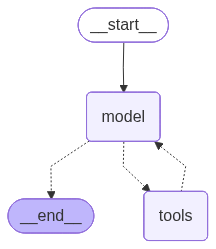

In [7]:
agent

## Step 6: Test It!

In [8]:
# Run a research query


topic = """I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance. 
My goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their ambiance,
including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified preferences
regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities, so these
should be considered flexible unless they are relevant to ambiance. Please prioritize information from official
coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible local
publications. The research should be current as of October 2025."""



In [9]:
with tracer.start_as_current_span("research_agent_tool"):
    initial_state = {
        "messages": [HumanMessage(content=topic)]
    }
    
    result = agent.invoke(initial_state)

💭 Thinking: To address the research question, I'll need to focus on identifying coffee shops in Seattle that are...
🔍 Searching: best coffee shop ambiances in Seattle October 2025
💭 Thinking: The initial search yielded two useful sources:

1. **Yelp**: A list of the top 10 coffee shops with ...
🔍 Searching: Storyville Coffee Company Seattle reviews ambiance
🔍 Searching: Sugar Bakery Seattle reviews ambiance
🔍 Searching: Drip Drip Coffeehouse Seattle reviews ambiance
🔍 Searching: Coffeeholic House Seattle reviews ambiance
💭 Thinking: From the search results, I gathered the following insights into the ambiance of the selected coffee ...
🔍 Searching: Sugar Bakery Seattle ambiance reviews
🔍 Searching: Storyville Coffee Company official website ambiance
🔍 Searching: Drip Drip Coffeehouse official website ambiance
🔍 Searching: Coffeeholic House official website ambiance
📝 Summarizing 1308 chars of findings


In [10]:
result

{'messages': [HumanMessage(content='I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance. \nMy goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their ambiance,\nincluding factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified preferences\nregarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities, so these\nshould be considered flexible unless they are relevant to ambiance. Please prioritize information from official\ncoffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible local\npublications. The research should be current as of October 2025.', additional_kwargs={}, response_metadata={}, id='00d7c58f-6c9b-4925-82f7-b0c490aec3a0'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 

In [11]:
from utils import format_message

In [12]:
format_message(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance.         │
│ My goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their     │
│ ambiance,                                                                                                       │
│ including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified          │
│ preferences                                                                                                     │
│ regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities,  │
│ so these                                                                                                        │
│ should be considered flexible unless they are relevant to ambiance. Please prioritize information from official │
│ coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible   │
│ local                                                                                                           │
│ publications. The research should be current as of October 2025.                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think                                                                                             │
│    Args: {                                                                                                      │
│   "reasoning": "To address the research question, I'll need to focus on identifying coffee shops in Seattle     │
│ that are renowned for their ambiance. Key aspects to consider include:\n\n1. **Interior Design**: What is       │
│ unique or notable about the design of the coffee shop?\n2. **Atmosphere**: What kind of mood or vibe does the   │
│ shop create?\n3. **Comfort**: Are the seating and environment conducive to relaxation or work?\n4. **Overall    │
│ Vibe**: How do these elements combine to create a unique experience?\n\nI will target the following types of    │
│ sources:\n- Official websites of coffee shops to see how they describe their ambiance.\n- Reputable review      │
│ platforms like Google Reviews, Yelp, and TripAdvisor for customer opinions.\n- Credible local publications in   │
│ Seattle that might have articles or lists about the best coffee shop ambiances.\n\nI plan to conduct multiple   │
│ searches:\n1. Search for lists or articles about the best coffee shop ambiances in Seattle from local           │
│ publications.\n2. Look for reviews and descriptions of ambiance on platforms like Yelp, Google Reviews, and     │
│ TripAdvisor for specific coffee shops.\n3. Visit the official websites of identified top coffee shops to gather │
│ descriptions of their ambiance.\n\nI'll begin with a search for recent articles or lists from local             │
│ publications that highlight Seattle coffee shops known for their ambiance."                                     │
│ }                                                                                                               │
│    ID: call_EpBawQMKS01QFvUHfT6POjqr                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reasoning recorded: To address the research question, I'll need to focus on identifying coffee shops in Seattle │
│ that are renowned for their ambiance. Key aspects to consider include:                                          │
│                                                                                                                 │
│ 1. **Interior Design**: What is unique or notable about the design of the coffee shop?                          │
│ 2. **Atmosphere**: What kind of mood or vibe does the shop create?                                              │
│ 3. **Comfort**: Are the seating and environment conducive to relaxation or work?                                │
│ 4. **Overall Vibe**: How do these elements combine to create a unique experience?                               │
│                                                                                                                 │
│ I will target the following types of sources:                                                                   │
│ - Official websites of coffee shops to see how they describe their ambiance.                                    │
│ - Reputable review platforms like Google Reviews, Yelp, and TripAdvisor for customer opinions.                  │
│ - Credible local publications in Seattle that might have articles or lists about the best coffee shop           │
│ ambiances.                                                                                                      │
│                                                                                                                 │
│ I plan to conduct multiple searches:                                                                            │
│ 1. Search for lists or articles about the best coffee shop ambiances in Seattle from local publications.        │
│ 2. Look for reviews and descriptions of ambiance on platforms like Yelp, Google Reviews, and TripAdvisor for    │
│ specific coffee shops.                                                                                          │
│ 3. Visit the official websites of identified top coffee shops to gather descriptions of their ambiance.         │
│                                                                                                                 │
│ I'll begin with a search for recent articles or lists from local publications that highlight Seattle coffee     │
│ shops known for their ambiance.                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: web_search                                                                                        │
│    Args: {                                                                                                      │
│   "query": "best coffee shop ambiances in Seattle October 2025",                                                │
│   "max_results": 3                                                                                              │
│ }                                                                                                               │
│    ID: call_CSe9b1xaBAFj2SC7yn5WT0Hr                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results for: 'best coffee shop ambiances in Seattle October 2025'                                        │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Seattle's Best Coffee Celebrates 25 ปี Years of Great Taste with New ... ---                       │
│ URL: https://www.instagram.com/reel/DOFwDO7Dhpj/                                                                │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ Seattle's Best Coffee has reopened its newly renovated store.                                                   │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ 'Our newly renovated Seattle's Best Coffee store is now open.'                                                  │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│ --- SOURCE 2: TOP 10 BEST Coffee Shops With Ambience in Seattle, WA - Yelp ---                                  │
│ URL: https://www.yelp.com/search?find_desc=Coffee+Shops+With+Ambience&find_loc=Seattle%2C+WA                    │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ This webpage lists the top 10 coffee shops near Seattle, Washington that are notable for their pleasant         │
│ ambience. The featured shops include Storyville Coffee Company, Sugar Bakery, Drip Drip Coffeehouse, and        │
│ Coffeeholic House among others.                                                                                 │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ 1. Storyville Coffee Company                                                                                    │
│ 2. Sugar Bakery                                                                                                 │
│ 3. Drip Drip Coffeehouse                                                                                        │
│ 4. Coffeeholic House                                                                                            │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                       

...

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results for: 'Coffeeholic House official website ambiance'                                               │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Coffeeholic House - Reviews, Photos & Phone Number ... ---                                        │
│ URL: https://coffeeholic-house.wheree.com/                                                                      │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ The webpage describes a warm and welcoming ambiance, perfect for socializing or enjoying a quiet moment with    │
│ coffee.                                                                                                         │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ "The ambiance is described as warm and welcoming...an ideal spot for socializing or enjoying a moment of        │
│ solitude with a delicious cup of coffee."                                                                       │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results for: 'Drip Drip Coffeehouse official website ambiance'                                           │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Drip Drip Coffeehouse ---                                                                         │
│ URL: https://dripdripcoffeehouse.com/                                                                           │
│                                                                                                                 │
│ <summary>                                                                                                       │
│ Drip Drip Coffee House focuses on creating a joyful experience through their coffee offerings in a cozy         │
│ atmosphere. They serve various coffee styles including Phin brewed coffee and have a selection of non-coffee    │
│ beverages and an espresso station to cater to different preferences.                                            │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ "Making your day brighter, one cup of coffee at a time."                                                        │
│ "Brewing Happiness, Spreading Smiles"                                                                           │
│ "Join us for a cozy atmosphere and a delicious cup to kickstart your day!"                                      │
│ "355 15th Ave, Seattle, WA, United States"                                                                      │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: summarize_findings                                                                                │
│    Args: {                                                                                                      │
│   "findings": "### Storyville Coffee Company\n- **Ambiance**: Located on the second floor of Pike Place Market, │
│ providing a cozy and welcoming atmosphere with views of the market. Known for its friendly staff and excellent  │
│ customer service, enhancing the ambiance.\n- **Official Website**: No specific ambiance details found on their  │
│ website. The focus is more on product offerings and discounts.\n\n### Sugar Bakery\n- **Ambiance**: Specific    │
│ ambiance details were not found. It is a highly-rated destination but lacks detailed reviews on ambiance.\n-    │
│ **General Info**: Located at 1014 Madison St, with a high rating of 4.4 stars based on over 600 reviews.\n\n### │
│ Drip Drip Coffeehouse\n- **Ambiance**: Offers a cozy atmosphere described as \"welcoming\" for coffee lovers.   │
│ Known for specialty drinks and snacks that add to the ambiance.\n- **Official Website**: Emphasizes a joyful    │
│ and cozy coffee experience, highlighting a variety of coffee styles and a welcoming environment.\n\n###         │
│ Coffeeholic House\n- **Ambiance**: Despite lacking seating, it is rated highly for ambiance, described as       │
│ \"cute\" and attractive. Known for a warm and welcoming ambiance ideal for socializing or enjoying a quiet      │
│ moment.\n- **Official Website**: Describes a warm and inviting ambiance, perfect for both socializing and       │
│ solitude with a good cup of coffee."                                                                            │
│ }                                                                                                               │
│    ID: call_QuPDSDvjzqCYnVF3ttjSehPp                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ **Summary**                                                                                                     │
│                                                                                                                 │
│ - **Storyville Coffee Company**: Located on the second floor of Pike Place Market, this coffee shop offers a    │
│ cozy and welcoming atmosphere with scenic views of the market. It is well-regarded for its friendly staff and   │
│ excellent customer service, which enhance the ambiance. However, their official website does not provide        │
│ specific details about the ambiance, focusing more on product offerings and discounts instead [1].              │
│                                                                                                                 │
│ - **Sugar Bakery**: Situated at 1014 Madison St, Sugar Bakery is a highly-rated establishment with a 4.4-star   │
│ average from over 600 reviews. Despite its high rating, there are no detailed reviews available regarding its   │
│ ambiance [2].                                                                                                   │
│                                                                                                                 │
│ - **Drip Drip Coffeehouse**: This coffeehouse provides a cozy and welcoming atmosphere, particularly noted by   │
│ coffee enthusiasts. Known for its specialty drinks and snacks, these elements contribute positively to the      │
│ ambiance. Their official website emphasizes a joyful and cozy coffee experience, highlighting a variety of      │
│ coffee styles and a welcoming environment [1].                                                                  │
│                                                                                                                 │
│ - **Coffeeholic House**: Even though it lacks seating, Coffeeholic House is praised for its ambiance, described │
│ as cute and attractive. It is known for offering a warm and welcoming atmosphere, ideal for both socializing    │
│ and enjoying a quiet moment. Their official website describes the ambiance as warm and inviting, suitable for   │
│ both social activities and solitary moments with good coffee [2].                                               │
│                                                                                                                 │
│ **Sources**                                                                                                     │
│ [1] Source 1                                                                                                    │
│ [2] Source 2                                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Here are the findings on the ambiance of some of Seattle's top coffee shops:                                    │
│                                                                                                                 │
│ ### Storyville Coffee Company                                                                                   │
│ - **Location**: Second floor of Pike Place Market.                                                              │
│ - **Ambiance**: Offers a cozy and welcoming atmosphere with views of the market. Renowned for its friendly      │
│ staff and excellent customer service.                                                                           │
│ - **Official Website**: Focuses more on product offerings rather than ambiance details.                         │
│                                                                                                                 │
│ ### Sugar Bakery                                                                                                │
│ - **Location**: 1014 Madison St.                                                                                │
│ - **Ambiance**: Lacks specific reviews regarding ambiance despite a high rating of 4.4 stars from over 600      │
│ reviews.                                                                                                        │
│                                                                                                                 │
│ ### Drip Drip Coffeehouse                                                                                       │
│ - **Ambiance**: Known for a cozy atmosphere and a welcoming vibe. Offers specialty drinks and snacks that       │
│ enhance the ambiance.                                                                                           │
│ - **Official Website**: Highlights a joyful and cozy coffee experience, emphasizing a welcoming environment.    │
│                                                                                                                 │
│ ### Coffeeholic House                                                                                           │
│ - **Ambiance**: Highly rated for ambiance despite no seating, described as cute and attractive. Known for a     │
│ warm and welcoming environment ideal for socializing or quiet moments.                                          │
│ - **Official Website**: Describes the ambiance as warm and inviting, perfect for both social and solitary       │
│ coffee enjoyment.                                                                                               │
│                                                                                                                 │
│ These coffee shops are noted for their unique atmospheres, contributing to Seattle's vibrant coffee culture. If │
│ ambiance is your primary focus, these places offer diverse experiences from cozy views to inviting social       │
│ environments.                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [13]:
# Display final answer nicely
from rich.markdown import Markdown
from IPython.display import display

for msg in reversed(result["messages"]):
    if isinstance(msg, AIMessage) and msg.content and not msg.tool_calls:
        display(Markdown(msg.content))
        break

Here are the findings on the ambiance of some of Seattle's top coffee shops:                                       

                                             Storyville Coffee Company                                             

 • Location: Second floor of Pike Place Market.                                                                    
 • Ambiance: Offers a cozy and welcoming atmosphere with views of the market. Renowned for its friendly staff and  
   excellent customer service.                                                                                     
 • Official Website: Focuses more on product offerings rather than ambiance details.                               

                                                   Sugar Bakery                                                    

 • Location: 1014 Madison St.                                                                                      
 • Ambiance: Lacks specific reviews regarding ambiance despite a high rating of 4.4 stars from over 600 reviews.   

                                               Drip Drip Coffeehouse                                               

 • Ambiance: Known for a cozy atmosphere and a welcoming vibe. Offers specialty drinks and snacks that enhance the 
   ambiance.                                                                                                       
 • Official Website: Highlights a joyful and cozy coffee experience, emphasizing a welcoming environment.          

                                                 Coffeeholic House                                                 

 • Ambiance: Highly rated for ambiance despite no seating, described as cute and attractive. Known for a warm and  
   welcoming environment ideal for socializing or quiet moments.                                                   
 • Official Website: Describes the ambiance as warm and inviting, perfect for both social and solitary coffee      
   enjoyment.                                                                                                      

These coffee shops are noted for their unique atmospheres, contributing to Seattle's vibrant coffee culture. If    
ambiance is your primary focus, these places offer diverse experiences from cozy views to inviting social          
environments.